# A2: From Trees to Neural Networks
## Home Credit Default Risk Pipeline

---

## Phase 0: Setup

In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split, GridSearchCV, RandomizedSearchCV,
    cross_val_score, learning_curve, validation_curve
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, precision_recall_curve,
    confusion_matrix, classification_report, roc_curve
)

from xgboost import XGBClassifier
import xgboost as xgb

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot style
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

---

## Phase 1: Data Preparation

**Dataset:** [Home Credit Default Risk](https://www.kaggle.com/c/home-credit-default-risk)  
**Task:** Predict whether an applicant will repay a loan (TARGET: 0 = repay, 1 = default).

**Pipeline overview:**
1. Load & inspect → 2. Fix anomalies → 3. Drop high-missingness columns → 4. Create missing indicators → 5. Impute → 6. Engineer features → 7. Encode categoricals → 8. Split → 9. Scale (MLP only)

**Key constraints:**
- No data leakage: all preprocessing fit on training set only
- Same feature space for GBDT and MLP (controlled experiment)
- No supplementary tables (keep comparison focused on architecture, not feature engineering)

In [2]:
# --- Step 1.1: Load the Home Credit Default Risk dataset ---
DATA_DIR = './home-credit-default-risk'
df = pd.read_csv(os.path.join(DATA_DIR, 'application_train.csv'))

print(f"Dataset shape: {df.shape}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
df.head()

Dataset shape: (307511, 122)
Memory usage: 562.8 MB


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
# --- Step 1.2: Structure & metadata ---
TARGET_COL = 'TARGET'
ID_COL = 'SK_ID_CURR'

y = df[TARGET_COL].copy()
X = df.drop(columns=[TARGET_COL, ID_COL])

print(f"Features shape: {X.shape}")
print(f"\nTarget distribution:\n{y.value_counts()}")
print(f"\nDefault rate: {y.mean():.4f} (highly imbalanced — only ~8% defaults)")
print(f"\n--- Data types ---")
print(X.dtypes.value_counts())

Features shape: (307511, 120)

Target distribution:
TARGET
0    282686
1     24825
Name: count, dtype: int64

Default rate: 0.0807 (highly imbalanced — only ~8% defaults)

--- Data types ---
float64    65
int64      39
object     16
Name: count, dtype: int64


In [4]:
# --- Step 1.3: Summary statistics ---
print("--- Numerical feature statistics ---")
display(X.describe().T.head(20))

print("\n--- Categorical columns ---")
cat_cols = X.select_dtypes(include='object').columns.tolist()
print(f"Count: {len(cat_cols)}")
for col in cat_cols:
    print(f"  {col}: {X[col].nunique()} unique | "
          f"missing: {X[col].isnull().sum()} ({X[col].isnull().mean()*100:.1f}%)")

--- Numerical feature statistics ---


,count,mean,std,min,25%,50%,75%,max
CNT_CHILDREN,307511.0,0.417052,0.722121,0.00000,0.000000,0.00000,1.000000,1.900000e+01
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,25650.00000,112500.000000,147150.00000,202500.000000,1.170000e+08
AMT_CREDIT,307511.0,599025.999706,402490.776996,45000.00000,270000.000000,513531.00000,808650.000000,4.050000e+06
AMT_ANNUITY,307499.0,27108.573909,14493.737315,1615.50000,16524.000000,24903.00000,34596.000000,2.580255e+05
AMT_GOODS_PRICE,307233.0,538396.207429,369446.460540,40500.00000,238500.000000,450000.00000,679500.000000,4.050000e+06
REGION_POPULATION_RELATIVE,307511.0,0.020868,0.013831,0.00029,0.010006,0.01885,0.028663,7.250800e-02
DAYS_BIRTH,307511.0,-16036.995067,4363.988632,-25229.00000,-19682.000000,-15750.00000,-12413.000000,-7.489000e+03
DAYS_EMPLOYED,307511.0,63815.045904,141275.766519,-17912.00000,-2760.000000,-1213.00000,-289.000000,3.652430e+05
DAYS_REGISTRATION,307511.0,-4986.120328,3522.886321,-24672.00000,-7479.500000,-4504.00000,-2010.000000,0.000000e+00
DAYS_ID_PUBLISH,307511.0,-2994.202373,1509.450419,-7197.00000,-4299.000000,-3254.00000,-1720.000000,0.000000e+00



--- Categorical columns ---
Count: 16
  NAME_CONTRACT_TYPE: 2 unique | missing: 0 (0.0%)
  CODE_GENDER: 3 unique | missing: 0 (0.0%)
  FLAG_OWN_CAR: 2 unique | missing: 0 (0.0%)
  FLAG_OWN_REALTY: 2 unique | missing: 0 (0.0%)
  NAME_TYPE_SUITE: 7 unique | missing: 1292 (0.4%)
  NAME_INCOME_TYPE: 8 unique | missing: 0 (0.0%)
  NAME_EDUCATION_TYPE: 5 unique | missing: 0 (0.0%)
  NAME_FAMILY_STATUS: 6 unique | missing: 0 (0.0%)
  NAME_HOUSING_TYPE: 6 unique | missing: 0 (0.0%)
  OCCUPATION_TYPE: 18 unique | missing: 96391 (31.3%)
  WEEKDAY_APPR_PROCESS_START: 7 unique | missing: 0 (0.0%)
  ORGANIZATION_TYPE: 58 unique | missing: 0 (0.0%)
  FONDKAPREMONT_MODE: 4 unique | missing: 210295 (68.4%)
  HOUSETYPE_MODE: 3 unique | missing: 154297 (50.2%)
  WALLSMATERIAL_MODE: 7 unique | missing: 156341 (50.8%)
  EMERGENCYSTATE_MODE: 2 unique | missing: 145755 (47.4%)


Columns with missing values: 67 / 120


,missing_count,missing_pct
COMMONAREA_MEDI,214865,69.87
COMMONAREA_AVG,214865,69.87
COMMONAREA_MODE,214865,69.87
NONLIVINGAPARTMENTS_MEDI,213514,69.43
NONLIVINGAPARTMENTS_MODE,213514,69.43
NONLIVINGAPARTMENTS_AVG,213514,69.43
FONDKAPREMONT_MODE,210295,68.39
LIVINGAPARTMENTS_MODE,210199,68.35
LIVINGAPARTMENTS_MEDI,210199,68.35
LIVINGAPARTMENTS_AVG,210199,68.35


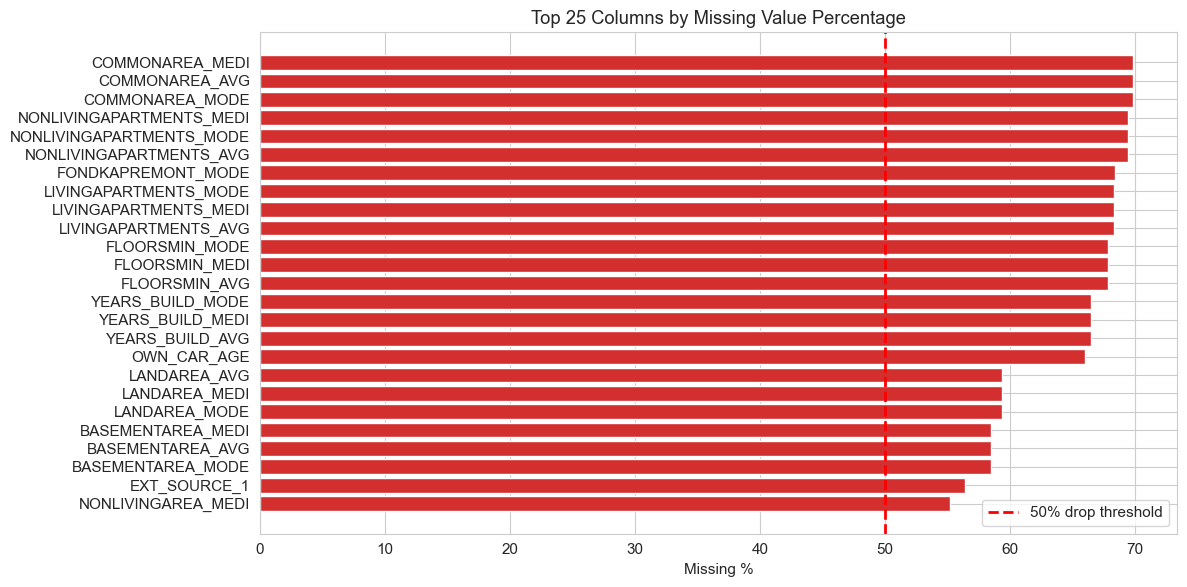

In [5]:
# --- Step 1.4: Identify and quantify missing values ---
n_rows = len(X)
missing_counts = X.isnull().sum()
missing_pct = (missing_counts / n_rows * 100).round(2)
missing_df = pd.DataFrame({
    'missing_count': missing_counts,
    'missing_pct': missing_pct
})
missing_df = missing_df[missing_df['missing_count'] > 0].sort_values('missing_pct', ascending=False)

print(f"Columns with missing values: {len(missing_df)} / {X.shape[1]}")
display(missing_df.head(20))

# Visualize missingness
fig, ax = plt.subplots(figsize=(12, 6))
top_missing = missing_df.head(25)
colors = ['#d32f2f' if pct > 50 else '#ff9800' if pct > 20 else '#4caf50'
          for pct in top_missing['missing_pct']]
ax.barh(top_missing.index, top_missing['missing_pct'], color=colors)
ax.axvline(x=50, color='red', linestyle='--', linewidth=2, label='50% drop threshold')
ax.set_xlabel('Missing %')
ax.set_title('Top 25 Columns by Missing Value Percentage')
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('figures/missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

### Step 1.5: Fix Anomalies

Two data quality issues require attention before proceeding:

1. **`DAYS_EMPLOYED` sentinel value (365,243):** 55,374 rows (18%) have this artificial value, representing pensioners/unemployed. This value is ~1,000 years — clearly not genuine employment duration. We replace it with `NaN` and create a binary indicator flag.

2. **`CODE_GENDER = 'XNA'`:** Only 4 rows have this indeterminate value. We drop these rows rather than impute (negligible data loss).

=== DAYS_EMPLOYED Anomaly ===
Rows with DAYS_EMPLOYED == 365243: 55,374 (18.0%)


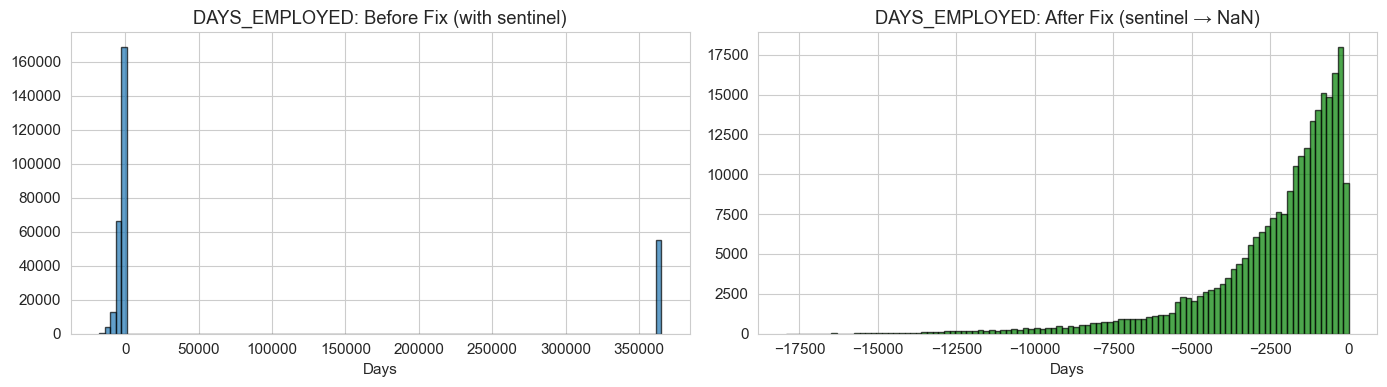

Created binary flag 'DAYS_EMPLOYED_ANOMALY'
DAYS_EMPLOYED after fix: min=-17912, max=0

=== CODE_GENDER Anomaly ===
Rows with CODE_GENDER == 'XNA': 4
Dropped 4 rows. New shape: (307507, 121)


In [6]:
# --- Step 1.5: Fix anomalies ---
X_clean = X.copy()

# 1. DAYS_EMPLOYED sentinel value: 365243 -> NaN + create binary flag
print("=== DAYS_EMPLOYED Anomaly ===")
anomaly_mask = X_clean['DAYS_EMPLOYED'] == 365243
print(f"Rows with DAYS_EMPLOYED == 365243: {anomaly_mask.sum():,} ({anomaly_mask.mean()*100:.1f}%)")

# Visualize the anomaly
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(X_clean['DAYS_EMPLOYED'], bins=100, edgecolor='black', alpha=0.7)
axes[0].set_title('DAYS_EMPLOYED: Before Fix (with sentinel)')
axes[0].set_xlabel('Days')

X_clean['DAYS_EMPLOYED_ANOMALY'] = anomaly_mask.astype(int)
X_clean.loc[anomaly_mask, 'DAYS_EMPLOYED'] = np.nan

axes[1].hist(X_clean['DAYS_EMPLOYED'].dropna(), bins=100, edgecolor='black', alpha=0.7, color='green')
axes[1].set_title('DAYS_EMPLOYED: After Fix (sentinel → NaN)')
axes[1].set_xlabel('Days')
plt.tight_layout()
plt.savefig('figures/days_employed_fix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Created binary flag 'DAYS_EMPLOYED_ANOMALY'")
print(f"DAYS_EMPLOYED after fix: min={X_clean['DAYS_EMPLOYED'].min():.0f}, "
      f"max={X_clean['DAYS_EMPLOYED'].max():.0f}")

# 2. CODE_GENDER: drop 4 'XNA' rows
print(f"\n=== CODE_GENDER Anomaly ===")
xna_mask = X_clean['CODE_GENDER'] == 'XNA'
print(f"Rows with CODE_GENDER == 'XNA': {xna_mask.sum()}")
X_clean = X_clean[~xna_mask]
y = y[~xna_mask]
print(f"Dropped {xna_mask.sum()} rows. New shape: {X_clean.shape}")

In [7]:
# --- Step 1.6: Drop columns with >50% missing ---
# EXCEPTION: Keep EXT_SOURCE_1 despite 56% missing (highly predictive external score)
DROP_THRESHOLD = 0.50

n_rows = len(X_clean)
missing_pct_updated = (X_clean.isnull().sum() / n_rows * 100)

cols_above_threshold = missing_pct_updated[missing_pct_updated > DROP_THRESHOLD * 100].index.tolist()

# Exception: keep EXT_SOURCE_1 — we will add a missing indicator instead
KEEP_DESPITE_MISSING = ['EXT_SOURCE_1']
cols_to_drop = [c for c in cols_above_threshold if c not in KEEP_DESPITE_MISSING]

print(f"Columns above {DROP_THRESHOLD*100:.0f}% missing: {len(cols_above_threshold)}")
print(f"Exceptions (kept with missing indicator): {KEEP_DESPITE_MISSING}")
print(f"Columns dropped: {len(cols_to_drop)}")

X_clean = X_clean.drop(columns=cols_to_drop)
print(f"\nShape after dropping: {X_clean.shape}")

Columns above 50% missing: 41
Exceptions (kept with missing indicator): ['EXT_SOURCE_1']
Columns dropped: 40

Shape after dropping: (307507, 81)


In [8]:
# --- Step 1.7: Create missing indicator flags (BEFORE imputation) ---
# These flags let MLP distinguish "real value" from "imputed value"
# (XGBoost handles NaN natively, but for a fair comparison we give MLP the same information)

MISSING_INDICATOR_COLS = ['EXT_SOURCE_1', 'EXT_SOURCE_3', 'OCCUPATION_TYPE']

for col in MISSING_INDICATOR_COLS:
    if col in X_clean.columns:
        flag_name = f'{col}_MISSING'
        X_clean[flag_name] = X_clean[col].isnull().astype(int)
        print(f"Created {flag_name}: {X_clean[flag_name].sum():,} flagged "
              f"({X_clean[flag_name].mean()*100:.1f}%)")

print(f"\nShape after adding indicators: {X_clean.shape}")

Created EXT_SOURCE_1_MISSING: 173,376 flagged (56.4%)
Created EXT_SOURCE_3_MISSING: 60,965 flagged (19.8%)
Created OCCUPATION_TYPE_MISSING: 96,389 flagged (31.3%)

Shape after adding indicators: (307507, 84)


In [9]:
# --- Step 1.8: Impute remaining missing values ---
# Strategy:
#   - Numerical: median (robust to outliers and skewed distributions)
#   - Categorical: 'Unknown' category (preserves the information that value was absent)

num_cols = X_clean.select_dtypes(include='number').columns.tolist()
cat_cols = X_clean.select_dtypes(include='object').columns.tolist()

num_imputed = 0
for col in num_cols:
    n_miss = X_clean[col].isnull().sum()
    if n_miss > 0:
        X_clean[col] = X_clean[col].fillna(X_clean[col].median())
        num_imputed += 1

cat_imputed = 0
for col in cat_cols:
    n_miss = X_clean[col].isnull().sum()
    if n_miss > 0:
        X_clean[col] = X_clean[col].fillna('Unknown')
        cat_imputed += 1

assert X_clean.isnull().sum().sum() == 0, "Missing values remain!"
print(f"Imputed {num_imputed} numerical columns (median)")
print(f"Imputed {cat_imputed} categorical columns ('Unknown')")
print(f"\n[SUCCESS] No missing values remaining. Shape: {X_clean.shape}")

Imputed 25 numerical columns (median)
Imputed 3 categorical columns ('Unknown')

[SUCCESS] No missing values remaining. Shape: (307507, 84)


In [10]:
# --- Step 1.9: Feature engineering ---
# Construct domain-informed features from existing columns

print("=== Feature Engineering ===\n")

# Age in years (DAYS_BIRTH is negative days before application)
X_clean['AGE_YEARS'] = (-X_clean['DAYS_BIRTH'] / 365.25).round(1)
print(f"AGE_YEARS: range [{X_clean['AGE_YEARS'].min():.1f}, {X_clean['AGE_YEARS'].max():.1f}]")

# Years employed (after sentinel fix + imputation)
X_clean['YEARS_EMPLOYED'] = (-X_clean['DAYS_EMPLOYED'] / 365.25).clip(lower=0)
print(f"YEARS_EMPLOYED: range [{X_clean['YEARS_EMPLOYED'].min():.1f}, {X_clean['YEARS_EMPLOYED'].max():.1f}]")

# Financial ratios
X_clean['INCOME_CREDIT_RATIO'] = X_clean['AMT_INCOME_TOTAL'] / (X_clean['AMT_CREDIT'] + 1e-8)
X_clean['ANNUITY_INCOME_RATIO'] = X_clean['AMT_ANNUITY'] / (X_clean['AMT_INCOME_TOTAL'] + 1e-8)
X_clean['CREDIT_GOODS_RATIO'] = X_clean['AMT_CREDIT'] / (X_clean['AMT_GOODS_PRICE'] + 1e-8)
X_clean['CREDIT_TERM'] = X_clean['AMT_ANNUITY'] / (X_clean['AMT_CREDIT'] + 1e-8)
print(f"Created 4 financial ratio features")

# Combined external source score
ext_cols = [c for c in ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3'] if c in X_clean.columns]
X_clean['EXT_SOURCE_MEAN'] = X_clean[ext_cols].mean(axis=1)
print(f"EXT_SOURCE_MEAN: range [{X_clean['EXT_SOURCE_MEAN'].min():.4f}, {X_clean['EXT_SOURCE_MEAN'].max():.4f}]")

new_features = ['AGE_YEARS', 'YEARS_EMPLOYED', 'INCOME_CREDIT_RATIO',
                'ANNUITY_INCOME_RATIO', 'CREDIT_GOODS_RATIO', 'CREDIT_TERM', 'EXT_SOURCE_MEAN']
print(f"\nNew features created: {len(new_features)}")
print(f"Shape after engineering: {X_clean.shape}")

=== Feature Engineering ===

AGE_YEARS: range [20.5, 69.1]
YEARS_EMPLOYED: range [-0.0, 49.0]
Created 4 financial ratio features
EXT_SOURCE_MEAN: range [0.0237, 0.8534]

New features created: 7
Shape after engineering: (307507, 91)


In [11]:
# --- Step 1.10: Encode categorical variables ---
CAT_COLS = X_clean.select_dtypes(include='object').columns.tolist()
print(f"Categorical columns to encode ({len(CAT_COLS)}):")
for col in CAT_COLS:
    print(f"  {col}: {X_clean[col].nunique()} unique values")

# One-hot encode all categoricals (drop_first=True to avoid multicollinearity)
X_encoded = pd.get_dummies(X_clean, columns=CAT_COLS, drop_first=True)

# Convert boolean columns to int
bool_cols = X_encoded.select_dtypes(include='bool').columns
if len(bool_cols) > 0:
    X_encoded[bool_cols] = X_encoded[bool_cols].astype(int)

print(f"\nFinal encoded feature shape: {X_encoded.shape}")
print(f"All features numeric: {X_encoded.select_dtypes(include='number').shape[1] == X_encoded.shape[1]}")

Categorical columns to encode (13):
  NAME_CONTRACT_TYPE: 2 unique values
  CODE_GENDER: 2 unique values
  FLAG_OWN_CAR: 2 unique values
  FLAG_OWN_REALTY: 2 unique values
  NAME_TYPE_SUITE: 8 unique values
  NAME_INCOME_TYPE: 8 unique values
  NAME_EDUCATION_TYPE: 5 unique values
  NAME_FAMILY_STATUS: 6 unique values
  NAME_HOUSING_TYPE: 6 unique values
  OCCUPATION_TYPE: 19 unique values
  WEEKDAY_APPR_PROCESS_START: 7 unique values
  ORGANIZATION_TYPE: 58 unique values
  EMERGENCYSTATE_MODE: 3 unique values

Final encoded feature shape: (307507, 193)
All features numeric: True


In [12]:
# --- Step 1.11: Train / Validation / Test split (70 / 15 / 15) ---
y_encoded = y.copy()

# First split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X_encoded, y_encoded, test_size=0.30,
    random_state=RANDOM_STATE, stratify=y_encoded
)
# Second split: 50% of temp -> 15% val, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50,
    random_state=RANDOM_STATE, stratify=y_temp
)

print(f"Train: {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X_encoded)*100:.1f}%)")
print(f"Val:   {X_val.shape[0]:,} samples ({X_val.shape[0]/len(X_encoded)*100:.1f}%)")
print(f"Test:  {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X_encoded)*100:.1f}%)")
print(f"\nDefault rates — Train: {y_train.mean():.4f} | Val: {y_val.mean():.4f} | Test: {y_test.mean():.4f}")
print(f"Feature count: {X_train.shape[1]}")

Train: 215,254 samples (70.0%)
Val:   46,126 samples (15.0%)
Test:  46,127 samples (15.0%)

Default rates — Train: 0.0807 | Val: 0.0807 | Test: 0.0807
Feature count: 193


In [13]:
# --- Step 1.12: Feature scaling (for MLP) ---
# IMPORTANT: Fit scaler on training data ONLY — no data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrames for interpretability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=X_val.columns, index=X_val.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("[SUCCESS] Phase 1 complete.")
print(f"  GBDT data: X_train {X_train.shape}, X_val {X_val.shape}, X_test {X_test.shape}")
print(f"  MLP data:  X_train_scaled {X_train_scaled.shape}, X_val_scaled, X_test_scaled")

[SUCCESS] Phase 1 complete.
  GBDT data: X_train (215254, 193), X_val (46126, 193), X_test (46127, 193)
  MLP data:  X_train_scaled (215254, 193), X_val_scaled, X_test_scaled


### Why is feature scaling necessary for MLP but not for GBDT?

**MLP (Neural Networks):** Gradient-based optimization is sensitive to feature scales. Features with large magnitudes (e.g., `AMT_CREDIT` ~ 10⁶) dominate the gradient updates compared to features with small magnitudes (e.g., `EXT_SOURCE_1` ~ [0, 1]). StandardScaler normalizes all features to zero mean and unit variance, ensuring each feature contributes proportionally to learning.

**GBDT (Tree-based):** Decision trees split on thresholds — they only compare values *within* a single feature using rank order. Whether a feature ranges [0, 1] or [0, 10⁶], the optimal split point is found the same way. Trees are therefore **invariant to monotonic transformations** of individual features, making scaling unnecessary.

**Additionally:** For features with median imputation (e.g., `EXT_SOURCE_1` at 56% missing), scaling does not resolve the fundamental issue — 56% of values map to the same point after StandardScaler. The missing indicator flags we created allow both models to learn this pattern explicitly.

---

## Phase 2: Gradient Boosted Decision Trees (GBDT)

Train an `XGBClassifier` and explore hyperparameters:
- `learning_rate`, `n_estimators`, `max_depth`
- `subsample`, `reg_alpha`, `reg_lambda`

Visualize:
- Training vs validation loss (with `eval_set` and early stopping)
- Feature importance
- Effect of learning rate (at least 3 values)

In [14]:
# --- Step 2.1: Baseline XGBClassifier ---
xgb_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    reg_alpha=0.0,
    reg_lambda=1.0,
    random_state=RANDOM_STATE,
    eval_metric='logloss',
    early_stopping_rounds=30,
    verbosity=0
)

t_start = time.time()
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=False
)
xgb_train_time = time.time() - t_start

y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

print(f"XGBoost baseline — Test Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"  F1: {f1_score(y_test, y_pred_xgb):.4f}")
print(f"  AUC-PR: {average_precision_score(y_test, y_proba_xgb):.4f}")
print(f"  Best iteration: {xgb_model.best_iteration}")
print(f"  Training time: {xgb_train_time:.2f}s")

XGBoost baseline — Test Accuracy: 0.9197
  F1: 0.0584
  AUC-PR: 0.2587
  Best iteration: 195
  Training time: 5.47s


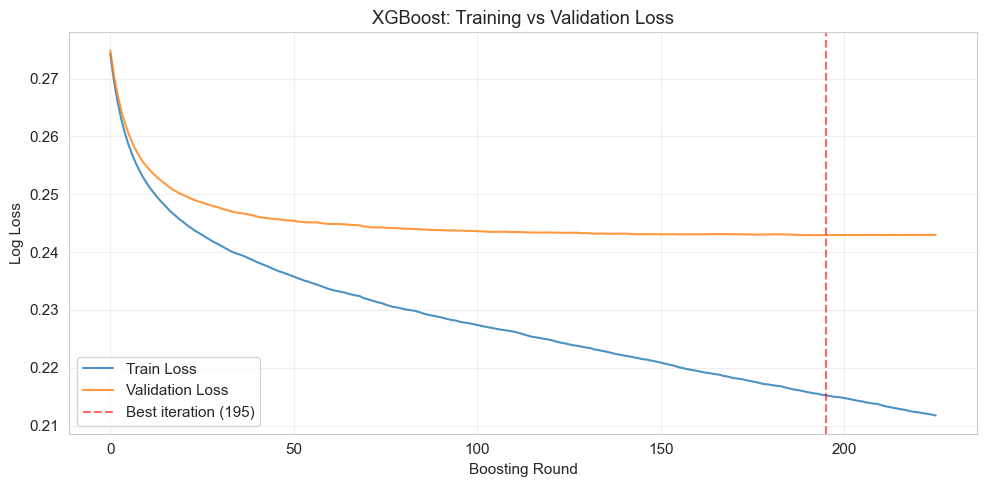

In [15]:
# --- Step 2.2: Training vs Validation loss curve ---
results = xgb_model.evals_result()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(results['validation_0']['logloss'], label='Train Loss', alpha=0.8)
ax.plot(results['validation_1']['logloss'], label='Validation Loss', alpha=0.8)
if xgb_model.best_iteration:
    ax.axvline(x=xgb_model.best_iteration, color='red', linestyle='--',
               alpha=0.6, label=f'Best iteration ({xgb_model.best_iteration})')
ax.set_xlabel('Boosting Round')
ax.set_ylabel('Log Loss')
ax.set_title('XGBoost: Training vs Validation Loss')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/gbdt_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()

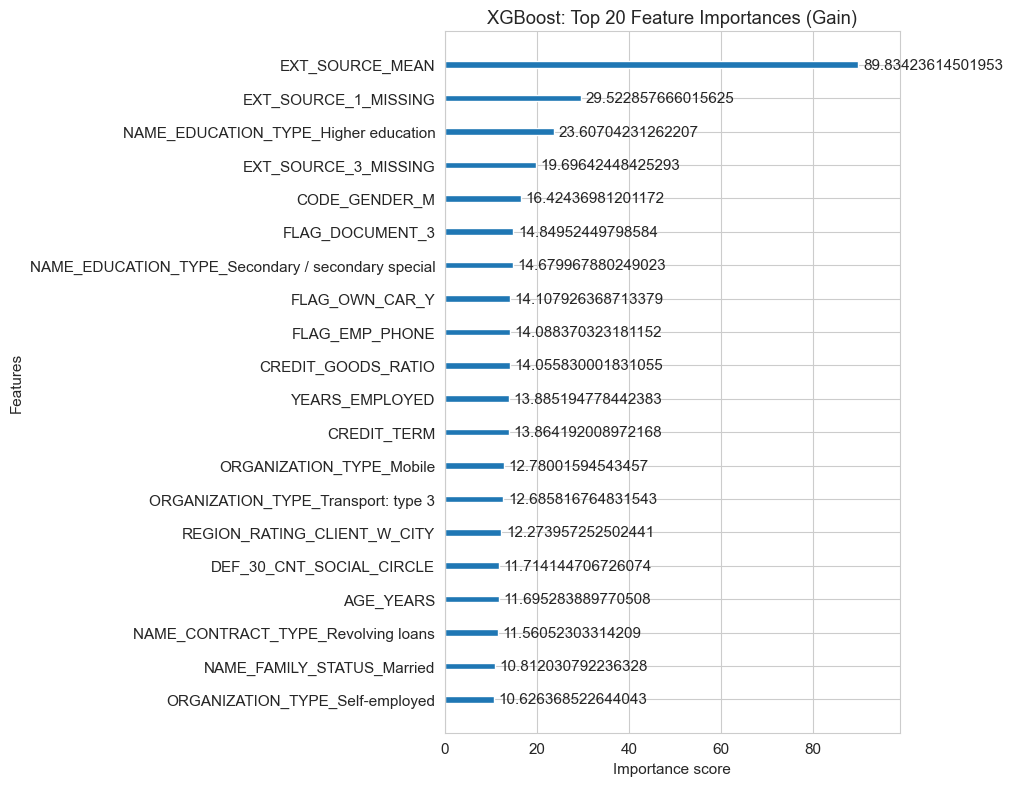

In [16]:
# --- Step 2.3: Feature importance ---
fig, ax = plt.subplots(figsize=(10, 8))
xgb.plot_importance(xgb_model, ax=ax, max_num_features=20, importance_type='gain')
ax.set_title('XGBoost: Top 20 Feature Importances (Gain)')
plt.tight_layout()
plt.savefig('figures/gbdt_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

LR=0.01: Acc=0.9196, F1=0.0196, AUC-PR=0.2577, Best iter=499
LR=0.1: Acc=0.9197, F1=0.0584, AUC-PR=0.2587, Best iter=195
LR=0.3: Acc=0.9198, F1=0.0699, AUC-PR=0.2448, Best iter=27


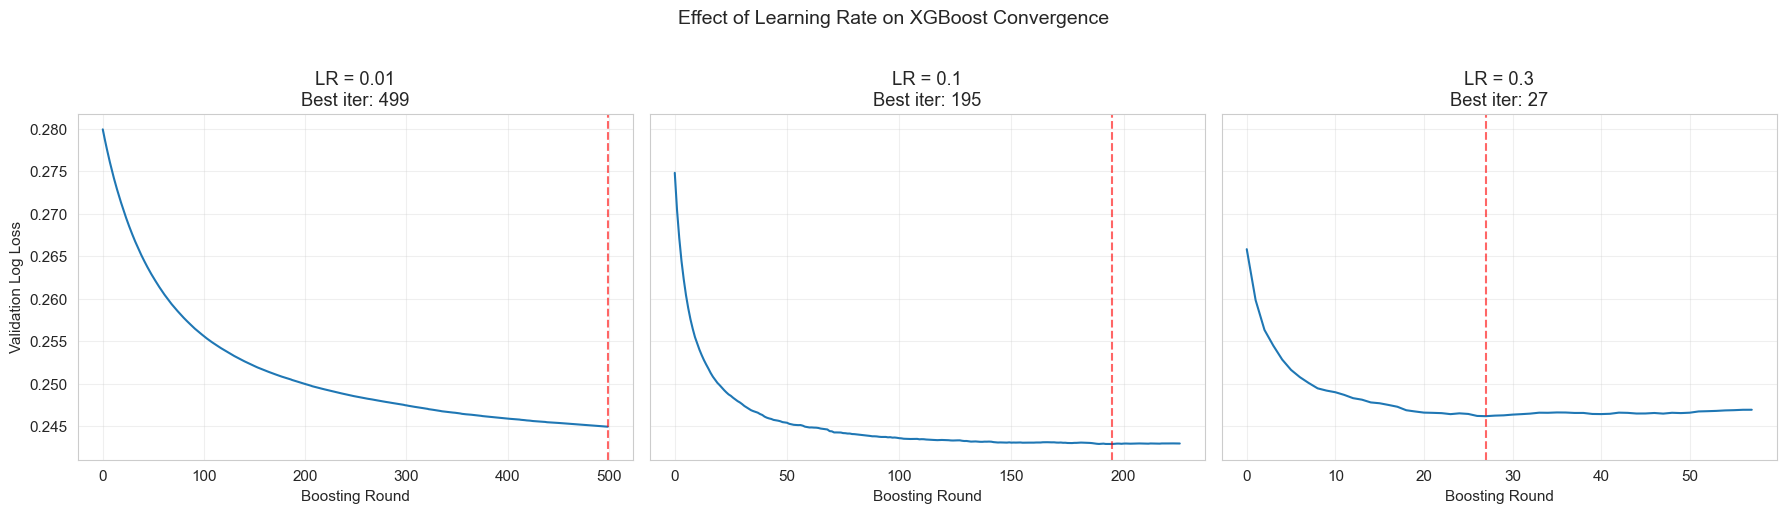

In [17]:
# --- Step 2.4: Effect of learning rate ---
learning_rates = [0.01, 0.1, 0.3]
lr_results = {}

fig, axes = plt.subplots(1, len(learning_rates), figsize=(18, 5), sharey=True)

for i, lr in enumerate(learning_rates):
    model = XGBClassifier(
        n_estimators=500,
        learning_rate=lr,
        max_depth=6,
        subsample=0.8,
        random_state=RANDOM_STATE,
        eval_metric='logloss',
        early_stopping_rounds=30,
        verbosity=0
    )
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    lr_results[lr] = {
        'model': model,
        'accuracy': accuracy_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'auc_pr': average_precision_score(y_test, y_proba),
        'best_iteration': model.best_iteration
    }
    # Plot validation loss curve
    val_loss = model.evals_result()['validation_0']['logloss']
    axes[i].plot(val_loss, linewidth=1.5)
    axes[i].axvline(x=model.best_iteration, color='red', linestyle='--', alpha=0.6)
    axes[i].set_title(f'LR = {lr}\nBest iter: {model.best_iteration}')
    axes[i].set_xlabel('Boosting Round')
    if i == 0:
        axes[i].set_ylabel('Validation Log Loss')
    axes[i].grid(alpha=0.3)
    
    print(f"LR={lr}: Acc={lr_results[lr]['accuracy']:.4f}, F1={lr_results[lr]['f1']:.4f}, "
          f"AUC-PR={lr_results[lr]['auc_pr']:.4f}, Best iter={lr_results[lr]['best_iteration']}")

plt.suptitle('Effect of Learning Rate on XGBoost Convergence', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('figures/gbdt_learning_rate_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

n_estimators=100: Acc=0.9199, F1=0.0430, AUC-PR=0.2588
n_estimators=300: Acc=0.9198, F1=0.0657, AUC-PR=0.2559
n_estimators=500: Acc=0.9197, F1=0.0698, AUC-PR=0.2508
n_estimators=1000: Acc=0.9193, F1=0.0850, AUC-PR=0.2402


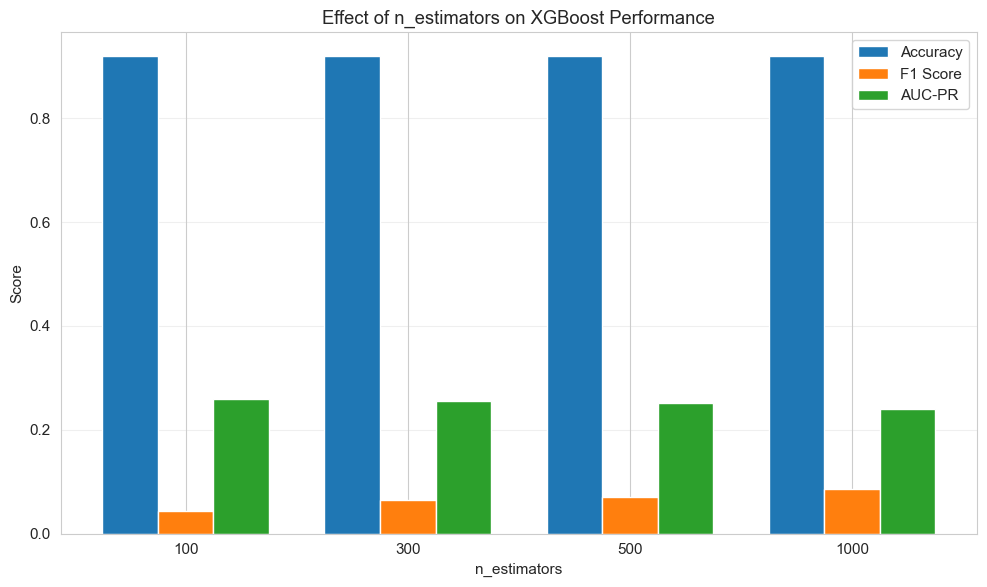

In [18]:
# --- Step 2.4b: Effect of n_estimators ---
n_estimators_list = [100, 300, 500, 1000]
n_est_results = {}

for n_est in n_estimators_list:
    model = XGBClassifier(
        n_estimators=n_est,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        random_state=RANDOM_STATE,
        eval_metric='logloss',
        verbosity=0
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    n_est_results[n_est] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'auc_pr': average_precision_score(y_test, y_proba),
    }
    print(f"n_estimators={n_est}: Acc={n_est_results[n_est]['accuracy']:.4f}, "
          f"F1={n_est_results[n_est]['f1']:.4f}, "
          f"AUC-PR={n_est_results[n_est]['auc_pr']:.4f}")

metrics = ['accuracy', 'f1', 'auc_pr']
metric_labels = ['Accuracy', 'F1 Score', 'AUC-PR']
x = np.arange(len(n_estimators_list))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
for j, (metric, label) in enumerate(zip(metrics, metric_labels)):
    values = [n_est_results[n][metric] for n in n_estimators_list]
    ax.bar(x + j * width, values, width, label=label)

ax.set_xlabel('n_estimators')
ax.set_ylabel('Score')
ax.set_title('Effect of n_estimators on XGBoost Performance')
ax.set_xticks(x + width)
ax.set_xticklabels(n_estimators_list)
ax.legend()
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('figures/gbdt_n_estimators_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

> **Note on flat accuracy:** All three learning rates in Step 2.4 yield nearly identical accuracy (~0.920). This occurs because the default decision threshold of 0.5 causes both models to predict the majority class (repay) for almost all instances — a direct consequence of the 8.07% class imbalance, not model indifference. The divergent AUC-PR and F1 scores confirm that the models do learn meaningfully different representations; accuracy simply fails to capture this under severe class imbalance.

In [19]:
# --- Step 2.5: Hyperparameter tuning ---
param_grid = {
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 6, 9],
    'subsample': [0.6, 0.8, 1.0],
    'reg_alpha': [0, 0.1, 1.0],
    'reg_lambda': [0.5, 1.0, 2.0],
}

base_xgb = XGBClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE, eval_metric='logloss', verbosity=0
)

random_search = RandomizedSearchCV(
    base_xgb, param_grid, n_iter=30, cv=3,
    scoring='average_precision', n_jobs=-1,
    random_state=RANDOM_STATE, verbose=1
)
random_search.fit(X_train, y_train)

print(f"\nBest params: {random_search.best_params_}")
print(f"Best AUC-PR (CV): {random_search.best_score_:.4f}")

Fitting 3 folds for each of 30 candidates, totalling 90 fits

Best params: {'subsample': 0.6, 'reg_lambda': 2.0, 'reg_alpha': 1.0, 'max_depth': 3, 'learning_rate': 0.1}
Best AUC-PR (CV): 0.2470


              precision    recall  f1-score   support

   Repay (0)       0.92      1.00      0.96     42403
 Default (1)       0.54      0.03      0.05      3724

    accuracy                           0.92     46127
   macro avg       0.73      0.51      0.50     46127
weighted avg       0.89      0.92      0.88     46127

AUC-PR: 0.2595
ROC-AUC: 0.7694
Best iteration: 499, Time: 8.22s


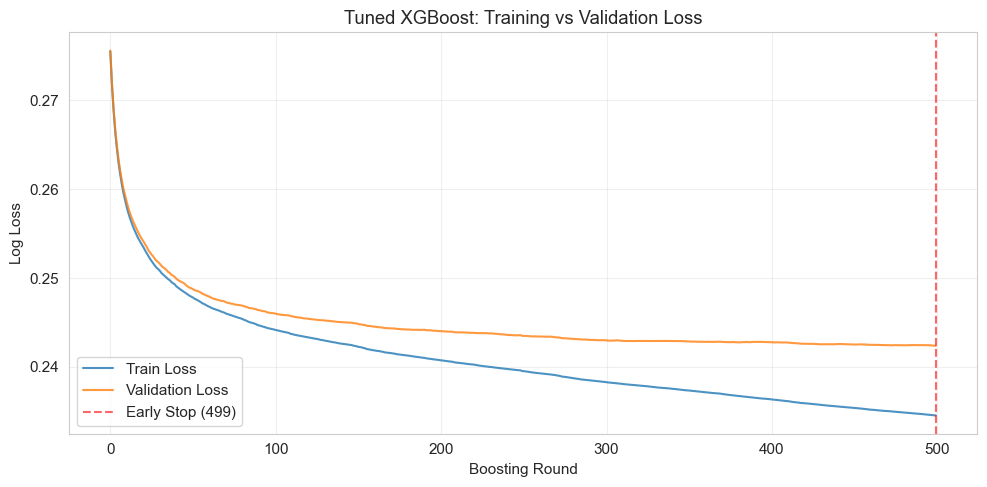

In [20]:
# --- Step 2.6: Final GBDT model (best configuration) ---
best_xgb = XGBClassifier(
    **random_search.best_params_,
    n_estimators=500,
    random_state=42, eval_metric='logloss',
    early_stopping_rounds=30, verbosity=0
)
t_start = time.time()
best_xgb.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_val, y_val)], verbose=False)
xgb_train_time = time.time() - t_start

y_pred_xgb_final = best_xgb.predict(X_test)
y_proba_xgb_final = best_xgb.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_xgb_final, target_names=['Repay (0)', 'Default (1)']))
print(f'AUC-PR: {average_precision_score(y_test, y_proba_xgb_final):.4f}')
print(f'ROC-AUC: {roc_auc_score(y_test, y_proba_xgb_final):.4f}')
print(f'Best iteration: {best_xgb.best_iteration}, Time: {xgb_train_time:.2f}s')

evals_tuned = best_xgb.evals_result()
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(evals_tuned['validation_0']['logloss'], label='Train Loss', alpha=0.8)
ax.plot(evals_tuned['validation_1']['logloss'], label='Validation Loss', alpha=0.8)
ax.axvline(x=best_xgb.best_iteration, color='red', linestyle='--',
           alpha=0.6, label=f'Early Stop ({best_xgb.best_iteration})')
ax.set_xlabel('Boosting Round'); ax.set_ylabel('Log Loss')
ax.set_title('Tuned XGBoost: Training vs Validation Loss')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/gbdt_tuned_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()


---

## Phase 3: Multi-Layer Perceptron (MLP)

Train an `MLPClassifier` (scikit-learn) and explore hyperparameters:
- `hidden_layer_sizes` (depth/width)
- `activation` (relu vs tanh)
- `learning_rate_init`
- `alpha` (L2 regularization — critical for sparse one-hot features)

**Note:** MLP uses the **scaled** data (`X_train_scaled`, `X_val_scaled`, `X_test_scaled`).

In [21]:
# --- Step 3.1: Baseline MLPClassifier ---
mlp_model = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    learning_rate_init=0.001,
    alpha=1e-4,
    max_iter=300,
    random_state=RANDOM_STATE,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=15,
    verbose=False
)

t_start = time.time()
mlp_model.fit(X_train_scaled, y_train)
mlp_train_time = time.time() - t_start

y_pred_mlp = mlp_model.predict(X_test_scaled)
y_proba_mlp = mlp_model.predict_proba(X_test_scaled)[:, 1]

print(f"MLP baseline — Test Accuracy: {accuracy_score(y_test, y_pred_mlp):.4f}")
print(f"  F1: {f1_score(y_test, y_pred_mlp):.4f}")
print(f"  AUC-PR: {average_precision_score(y_test, y_proba_mlp):.4f}")
print(f"  Epochs trained: {mlp_model.n_iter_}")
print(f"  Training time: {mlp_train_time:.2f}s")

MLP baseline — Test Accuracy: 0.9192
  F1: 0.0342
  AUC-PR: 0.2240
  Epochs trained: 20
  Training time: 11.13s


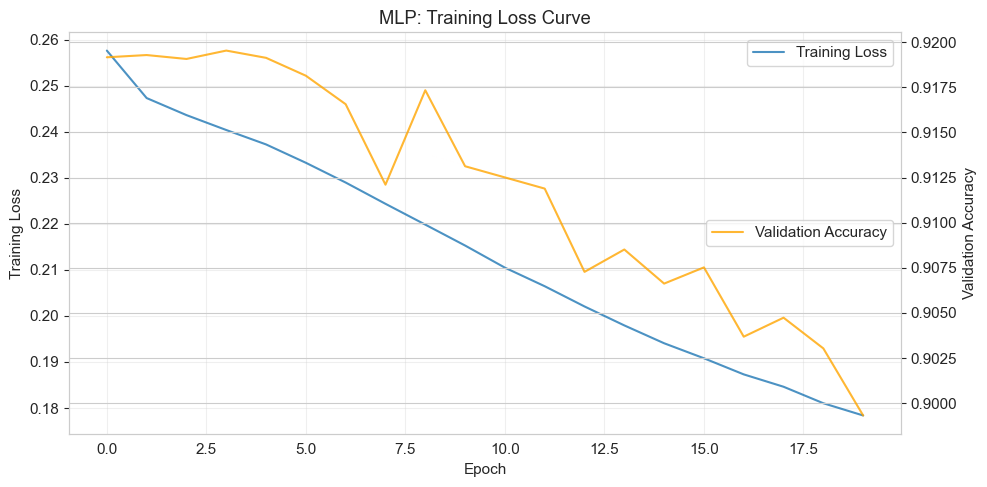

In [22]:
# --- Step 3.2: Training loss curve ---
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(mlp_model.loss_curve_, label='Training Loss', alpha=0.8)
if hasattr(mlp_model, 'validation_scores_') and mlp_model.validation_scores_ is not None:
    ax2 = ax.twinx()
    ax2.plot(mlp_model.validation_scores_, label='Validation Accuracy', color='orange', alpha=0.8)
    ax2.set_ylabel('Validation Accuracy')
    ax2.legend(loc='center right')
ax.set_xlabel('Epoch')
ax.set_ylabel('Training Loss')
ax.set_title('MLP: Training Loss Curve')
ax.legend(loc='upper right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/mlp_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()

Arch=(64,): Acc=0.9190, F1=0.0225, AUC-PR=0.2231, Epochs=19
Arch=(128, 64): Acc=0.9192, F1=0.0342, AUC-PR=0.2240, Epochs=20
Arch=(256, 128, 64): Acc=0.9193, F1=0.0190, AUC-PR=0.2271, Epochs=20


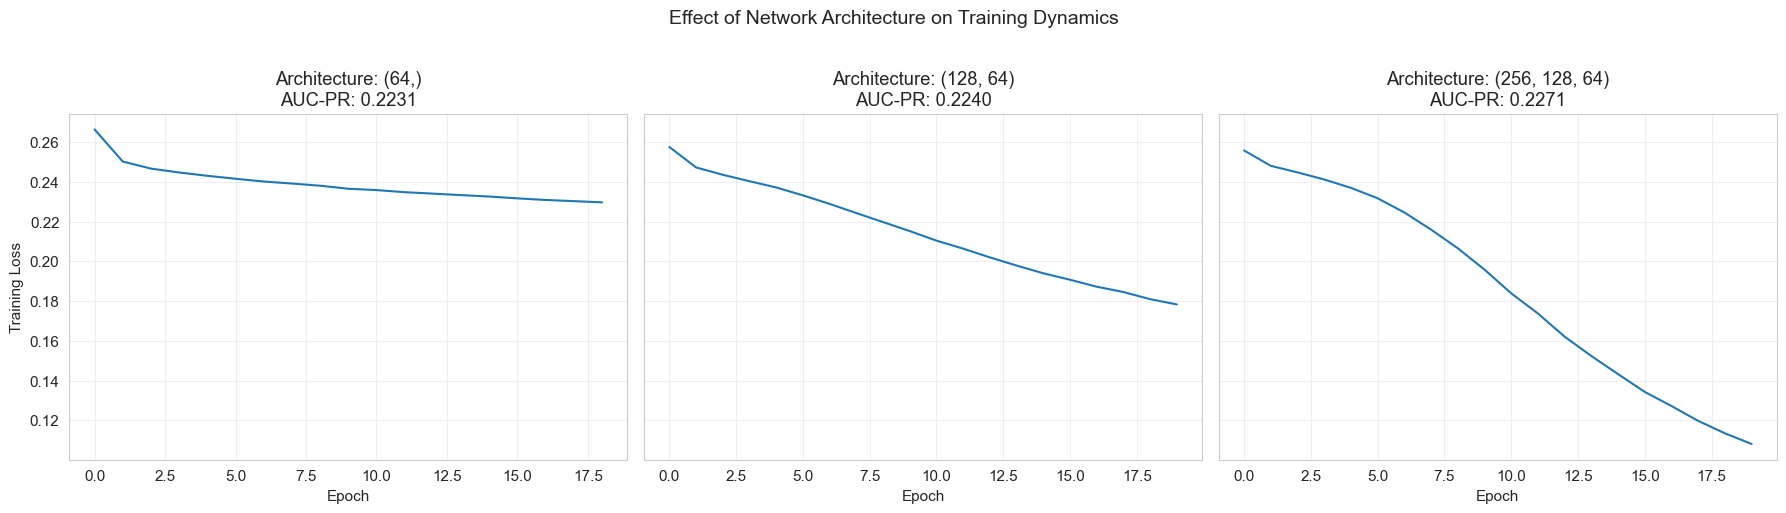

In [23]:
# --- Step 3.3: Effect of network depth/width ---
architectures = [
    (64,),
    (128, 64),
    (256, 128, 64),
]
arch_results = {}

for arch in architectures:
    model = MLPClassifier(
        hidden_layer_sizes=arch,
        activation='relu',
        learning_rate_init=0.001,
        alpha=1e-4,
        max_iter=300,
        random_state=RANDOM_STATE,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=15,
        verbose=False
    )
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    arch_results[str(arch)] = {
        'model': model,
        'accuracy': accuracy_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'auc_pr': average_precision_score(y_test, y_proba),
        'epochs': model.n_iter_
    }
    print(f"Arch={arch}: Acc={arch_results[str(arch)]['accuracy']:.4f}, "
          f"F1={arch_results[str(arch)]['f1']:.4f}, "
          f"AUC-PR={arch_results[str(arch)]['auc_pr']:.4f}, "
          f"Epochs={arch_results[str(arch)]['epochs']}")

# Visualize: loss curves for each architecture
fig, axes = plt.subplots(1, len(architectures), figsize=(18, 5), sharey=True)
for i, (arch_name, res) in enumerate(arch_results.items()):
    axes[i].plot(res['model'].loss_curve_)
    axes[i].set_title(f'Architecture: {arch_name}\nAUC-PR: {res["auc_pr"]:.4f}')
    axes[i].set_xlabel('Epoch')
    if i == 0:
        axes[i].set_ylabel('Training Loss')
    axes[i].grid(alpha=0.3)
plt.suptitle('Effect of Network Architecture on Training Dynamics', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('figures/mlp_architecture_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [24]:
# --- Step 3.4: Effect of activation function ---
activations = ['relu', 'tanh']
activation_results = {}

for act in activations:
    model = MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation=act,
        learning_rate_init=0.001,
        alpha=1e-4,
        max_iter=300,
        random_state=RANDOM_STATE,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=15,
        verbose=False
    )
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    activation_results[act] = {
        'model': model,
        'accuracy': accuracy_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'auc_pr': average_precision_score(y_test, y_proba),
    }
    print(f"Activation={act}: Acc={activation_results[act]['accuracy']:.4f}, "
          f"F1={activation_results[act]['f1']:.4f}, "
          f"AUC-PR={activation_results[act]['auc_pr']:.4f}")

Activation=relu: Acc=0.9192, F1=0.0342, AUC-PR=0.2240
Activation=tanh: Acc=0.9194, F1=0.0154, AUC-PR=0.2167


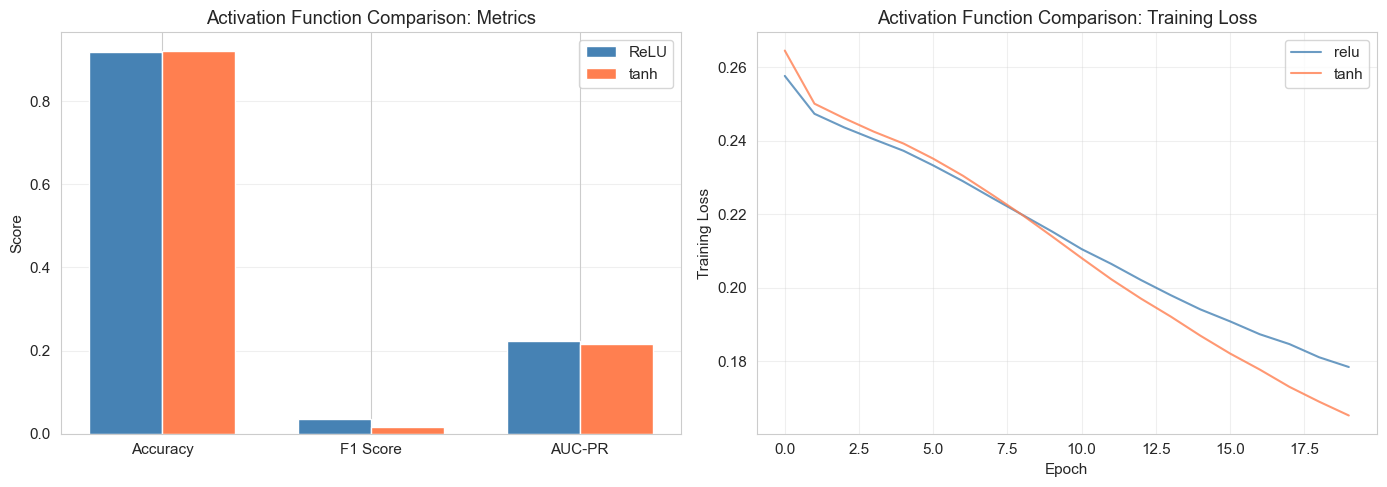

In [25]:
# --- Step 3.4b: Activation function comparison visualization ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart comparing metrics
metrics = ['accuracy', 'f1', 'auc_pr']
metric_labels = ['Accuracy', 'F1 Score', 'AUC-PR']
x = np.arange(len(metrics))
width = 0.35

relu_vals = [activation_results['relu'][m] for m in metrics]
tanh_vals = [activation_results['tanh'][m] for m in metrics]

ax1.bar(x - width/2, relu_vals, width, label='ReLU', color='steelblue')
ax1.bar(x + width/2, tanh_vals, width, label='tanh', color='coral')
ax1.set_ylabel('Score')
ax1.set_title('Activation Function Comparison: Metrics')
ax1.set_xticks(x)
ax1.set_xticklabels(metric_labels)
ax1.legend()
ax1.grid(alpha=0.3, axis='y')

# Training loss curves overlay
for act, color in [('relu', 'steelblue'), ('tanh', 'coral')]:
    loss = activation_results[act]['model'].loss_curve_
    ax2.plot(loss, label=f'{act}', color=color, alpha=0.8)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Training Loss')
ax2.set_title('Activation Function Comparison: Training Loss')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('figures/mlp_activation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
# --- Step 3.5: Effect of learning rate ---
mlp_learning_rates = [0.001, 0.01, 0.1]
mlp_lr_results = {}

for lr in mlp_learning_rates:
    model = MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation='relu',
        learning_rate_init=lr,
        alpha=1e-4,
        max_iter=300,
        random_state=RANDOM_STATE,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=15,
        verbose=False
    )
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    mlp_lr_results[lr] = {
        'model': model,
        'accuracy': accuracy_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'auc_pr': average_precision_score(y_test, y_proba),
        'epochs': model.n_iter_
    }
    print(f"LR={lr}: Acc={mlp_lr_results[lr]['accuracy']:.4f}, "
          f"F1={mlp_lr_results[lr]['f1']:.4f}, "
          f"AUC-PR={mlp_lr_results[lr]['auc_pr']:.4f}, "
          f"Epochs={mlp_lr_results[lr]['epochs']}")

LR=0.001: Acc=0.9192, F1=0.0342, AUC-PR=0.2240, Epochs=20
LR=0.01: Acc=0.9193, F1=0.0000, AUC-PR=0.2150, Epochs=17
LR=0.1: Acc=0.9193, F1=0.0000, AUC-PR=0.0808, Epochs=17


In [27]:
# --- Step 3.6: Effect of alpha (L2 regularization) ---
# Critical for preventing overfitting on sparse one-hot encoded features
alphas = [1e-5, 1e-4, 1e-3, 1e-2]
alpha_results = {}

for a in alphas:
    model = MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation='relu',
        learning_rate_init=0.001,
        alpha=a,
        max_iter=300,
        random_state=RANDOM_STATE,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=15,
        verbose=False
    )
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    alpha_results[a] = {
        'model': model,
        'accuracy': accuracy_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'auc_pr': average_precision_score(y_test, y_proba),
        'epochs': model.n_iter_
    }
    print(f"Alpha={a}: Acc={alpha_results[a]['accuracy']:.4f}, "
          f"F1={alpha_results[a]['f1']:.4f}, "
          f"AUC-PR={alpha_results[a]['auc_pr']:.4f}, "
          f"Epochs={alpha_results[a]['epochs']}")

Alpha=1e-05: Acc=0.9195, F1=0.0373, AUC-PR=0.2267, Epochs=17
Alpha=0.0001: Acc=0.9192, F1=0.0342, AUC-PR=0.2240, Epochs=20
Alpha=0.001: Acc=0.9195, F1=0.0388, AUC-PR=0.2218, Epochs=21
Alpha=0.01: Acc=0.9192, F1=0.0342, AUC-PR=0.2232, Epochs=21


Best arch: (256, 128, 64), activation: relu, LR: 0.001, alpha: 1e-05
              precision    recall  f1-score   support

   Repay (0)       0.92      1.00      0.96     42403
 Default (1)       0.58      0.00      0.01      3724

    accuracy                           0.92     46127
   macro avg       0.75      0.50      0.48     46127
weighted avg       0.89      0.92      0.88     46127

AUC-PR: 0.2320
ROC-AUC: 0.7498
Epochs: 18, Time: 19.69s


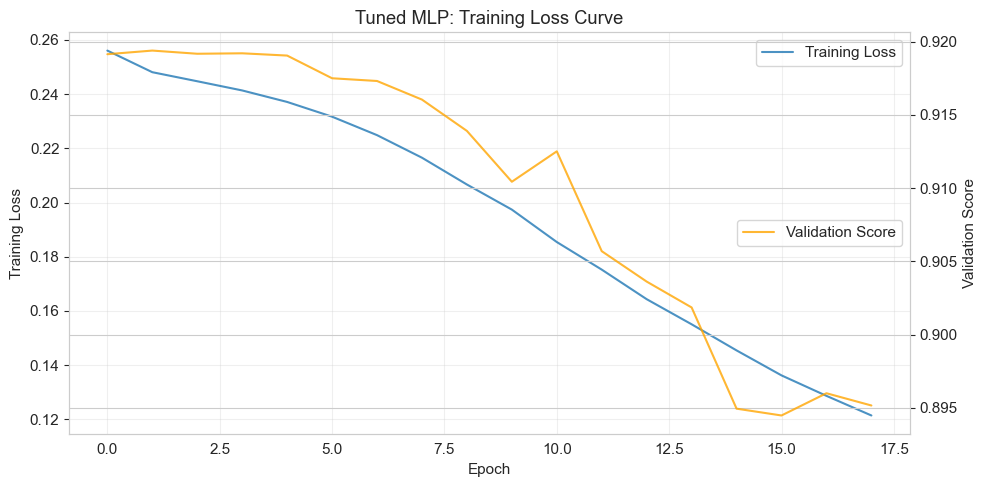

In [28]:
# --- Step 3.7: Final MLP model (best configuration) ---
import ast

best_arch_key = max(arch_results, key=lambda k: arch_results[k]['auc_pr'])
best_arch = ast.literal_eval(best_arch_key)
best_act = max(activation_results, key=lambda k: activation_results[k]['auc_pr'])
best_lr = max(mlp_lr_results, key=lambda k: mlp_lr_results[k]['auc_pr'])
best_alpha_key = max(alpha_results, key=lambda k: alpha_results[k]['auc_pr'])
best_alpha = float(best_alpha_key)

print(f'Best arch: {best_arch}, activation: {best_act}, LR: {best_lr}, alpha: {best_alpha}')

best_mlp = MLPClassifier(
    hidden_layer_sizes=best_arch, activation=best_act,
    learning_rate_init=best_lr, alpha=best_alpha, max_iter=300,
    random_state=42, early_stopping=True,
    validation_fraction=0.15, n_iter_no_change=15, verbose=False
)
t_start = time.time()
best_mlp.fit(X_train_scaled, y_train)
mlp_train_time = time.time() - t_start

y_pred_mlp_final = best_mlp.predict(X_test_scaled)
y_proba_mlp_final = best_mlp.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred_mlp_final, target_names=['Repay (0)', 'Default (1)']))
print(f'AUC-PR: {average_precision_score(y_test, y_proba_mlp_final):.4f}')
print(f'ROC-AUC: {roc_auc_score(y_test, y_proba_mlp_final):.4f}')
print(f'Epochs: {best_mlp.n_iter_}, Time: {mlp_train_time:.2f}s')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(best_mlp.loss_curve_, label='Training Loss', alpha=0.8)
if hasattr(best_mlp, 'validation_scores_') and best_mlp.validation_scores_ is not None:
    ax2 = ax.twinx()
    ax2.plot(best_mlp.validation_scores_, label='Validation Score', color='orange', alpha=0.8)
    ax2.set_ylabel('Validation Score')
    ax2.legend(loc='center right')
ax.set_xlabel('Epoch'); ax.set_ylabel('Training Loss')
ax.set_title('Tuned MLP: Training Loss Curve')
ax.legend(loc='upper right'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/mlp_tuned_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()


---

## Phase 4: GBDT vs MLP Comparison

Using the **same dataset** and **same train/test split** (no training-time imbalance correction for either model):

- **(a)** Compare both models on: Accuracy, Precision, Recall, F1-score, AUC-PR
- **(b)** Summary comparison table
- **(c)** Compare training time
- **(d)** Discussion

In [29]:
# --- Step 4.1: Side-by-side comparison ---
def compute_metrics(name, y_true, y_pred, y_proba, train_time):
    return {
        'Model': name,
        'Accuracy': round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall': round(recall_score(y_true, y_pred, zero_division=0), 4),
        'F1': round(f1_score(y_true, y_pred, zero_division=0), 4),
        'AUC-PR': round(average_precision_score(y_true, y_proba), 4),
        'ROC-AUC': round(roc_auc_score(y_true, y_proba), 4),
        'Train Time (s)': round(train_time, 2)
    }

comparison_results = [
    compute_metrics('XGBoost (GBDT)', y_test, y_pred_xgb_final, y_proba_xgb_final, xgb_train_time),
    compute_metrics('MLP', y_test, y_pred_mlp_final, y_proba_mlp_final, mlp_train_time),
]

comparison_df = pd.DataFrame(comparison_results).set_index('Model')
print("\n=== GBDT vs MLP — Comparison Table ===")
display(comparison_df)


=== GBDT vs MLP — Comparison Table ===


,Accuracy,Precision,Recall,F1,AUC-PR,ROC-AUC,Train Time (s)
Model,,,,,,,
XGBoost (GBDT),0.9196,0.5414,0.0263,0.0502,0.2595,0.7694,8.22
MLP,0.9194,0.5833,0.0038,0.0075,0.2320,0.7498,19.69


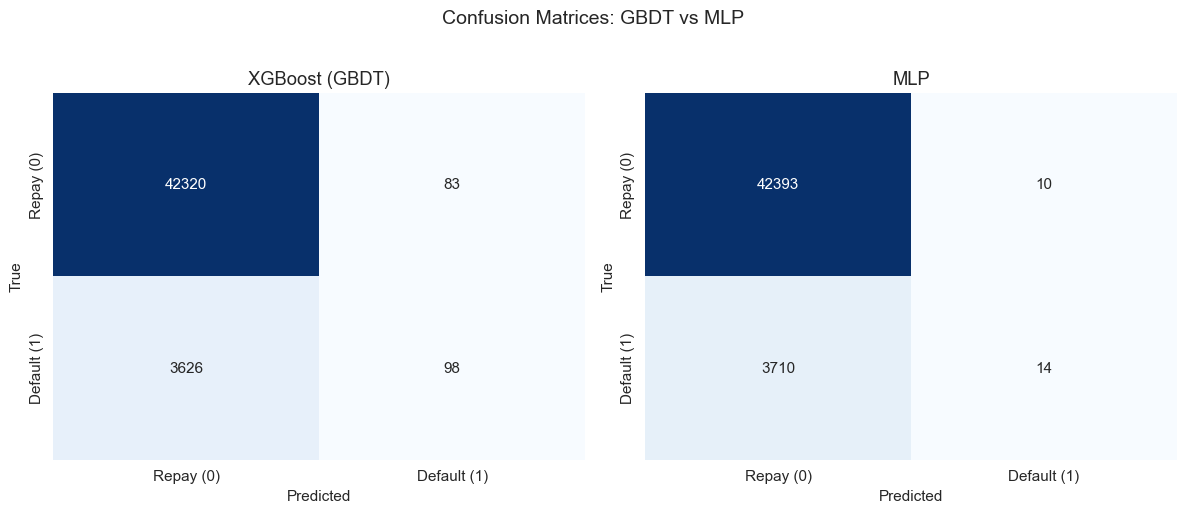

In [30]:
# --- Step 4.2: Confusion matrices ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
labels = ['Repay (0)', 'Default (1)']

for ax, (name, y_pred) in zip(axes, [
    ('XGBoost (GBDT)', y_pred_xgb_final),
    ('MLP', y_pred_mlp_final)
]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=labels, yticklabels=labels)
    ax.set_title(name)
    ax.set_ylabel('True')
    ax.set_xlabel('Predicted')

plt.suptitle('Confusion Matrices: GBDT vs MLP', y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig('figures/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

GBDT F1-optimal threshold (val): 0.1533  (val F1: 0.3200)
MLP  F1-optimal threshold (val): 0.1782  (val F1: 0.2936)


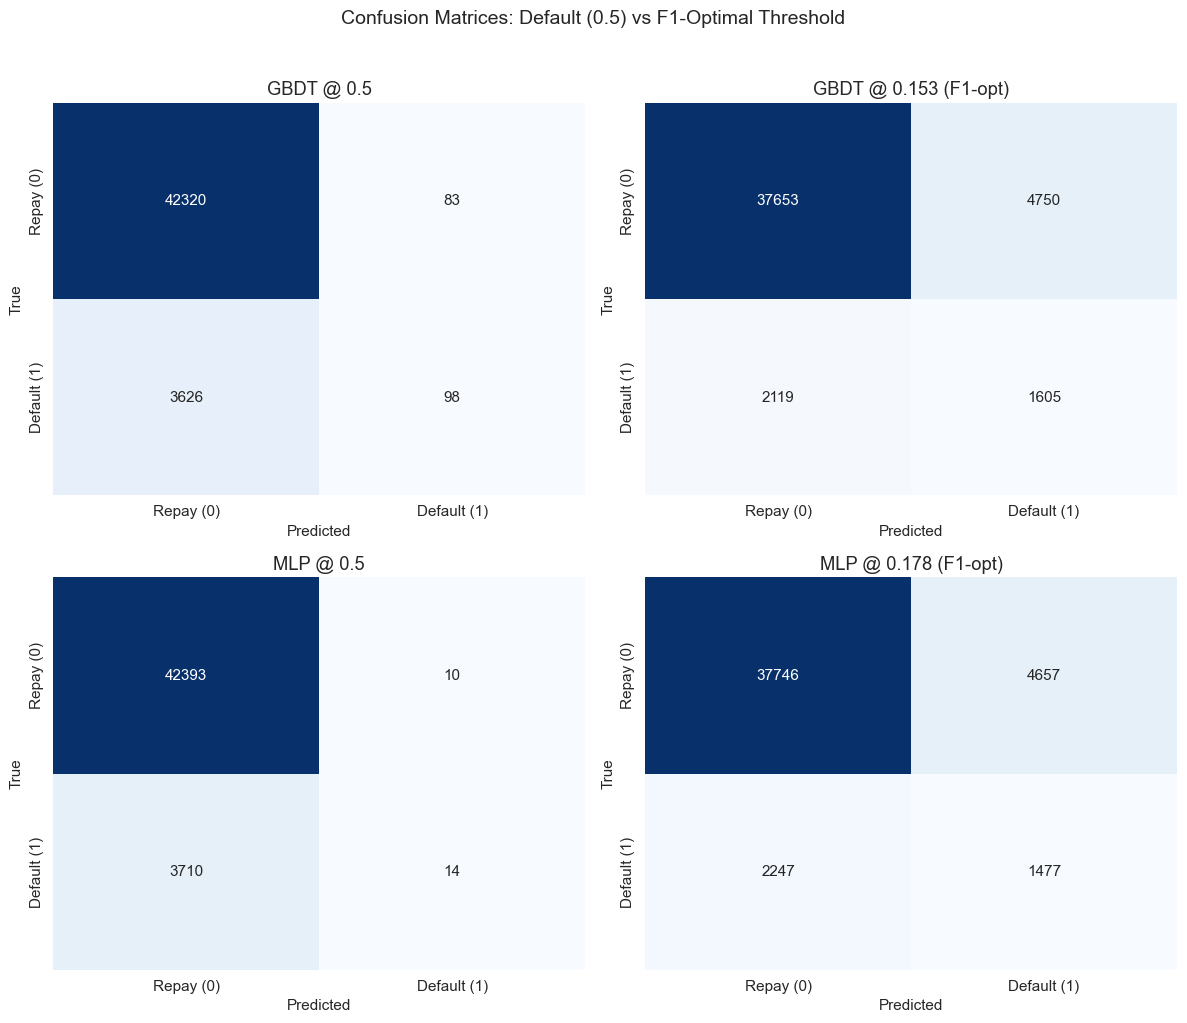

In [31]:
# --- Step 4.2b: Threshold analysis — F1-optimal vs default (0.5) ---

def find_f1_optimal_threshold(y_true, y_proba):
    """Find the threshold that maximizes F1 on the given set."""
    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
    best_idx = np.argmax(f1_scores)
    return thresholds[best_idx], f1_scores[best_idx]

y_val_proba_xgb = best_xgb.predict_proba(X_val)[:, 1]
y_val_proba_mlp = best_mlp.predict_proba(X_val_scaled)[:, 1]

thresh_xgb, f1_val_xgb = find_f1_optimal_threshold(y_val, y_val_proba_xgb)
thresh_mlp, f1_val_mlp = find_f1_optimal_threshold(y_val, y_val_proba_mlp)

print(f"GBDT F1-optimal threshold (val): {thresh_xgb:.4f}  (val F1: {f1_val_xgb:.4f})")
print(f"MLP  F1-optimal threshold (val): {thresh_mlp:.4f}  (val F1: {f1_val_mlp:.4f})")

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
labels = ['Repay (0)', 'Default (1)']

configs = [
    (0, 0, 'GBDT @ 0.5', y_proba_xgb_final, 0.5),
    (0, 1, f'GBDT @ {thresh_xgb:.3f} (F1-opt)', y_proba_xgb_final, thresh_xgb),
    (1, 0, 'MLP @ 0.5', y_proba_mlp_final, 0.5),
    (1, 1, f'MLP @ {thresh_mlp:.3f} (F1-opt)', y_proba_mlp_final, thresh_mlp),
]

for row, col, title, y_proba, threshold in configs:
    y_pred_t = (y_proba >= threshold).astype(int)
    cm = confusion_matrix(y_test, y_pred_t)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[row, col],
                cbar=False, xticklabels=labels, yticklabels=labels)
    axes[row, col].set_title(title)
    axes[row, col].set_ylabel('True')
    axes[row, col].set_xlabel('Predicted')

plt.suptitle('Confusion Matrices: Default (0.5) vs F1-Optimal Threshold', y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig('figures/confusion_matrices_threshold.png', dpi=150, bbox_inches='tight')
plt.show()

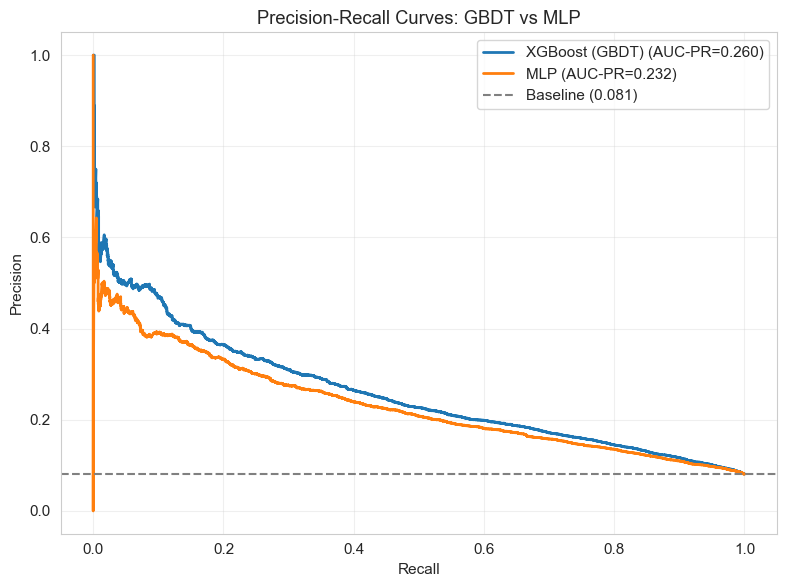

In [32]:
# --- Step 4.3: Precision-Recall curves ---
fig, ax = plt.subplots(figsize=(8, 6))

for name, y_proba in [
    ('XGBoost (GBDT)', y_proba_xgb_final),
    ('MLP', y_proba_mlp_final)
]:
    prec, rec, _ = precision_recall_curve(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)
    ax.plot(rec, prec, label=f'{name} (AUC-PR={ap:.3f})', lw=2)

# Baseline: fraction of positives
baseline = y_test.mean()
ax.axhline(y=baseline, color='gray', linestyle='--', label=f'Baseline ({baseline:.3f})')

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves: GBDT vs MLP')
ax.legend(loc='upper right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

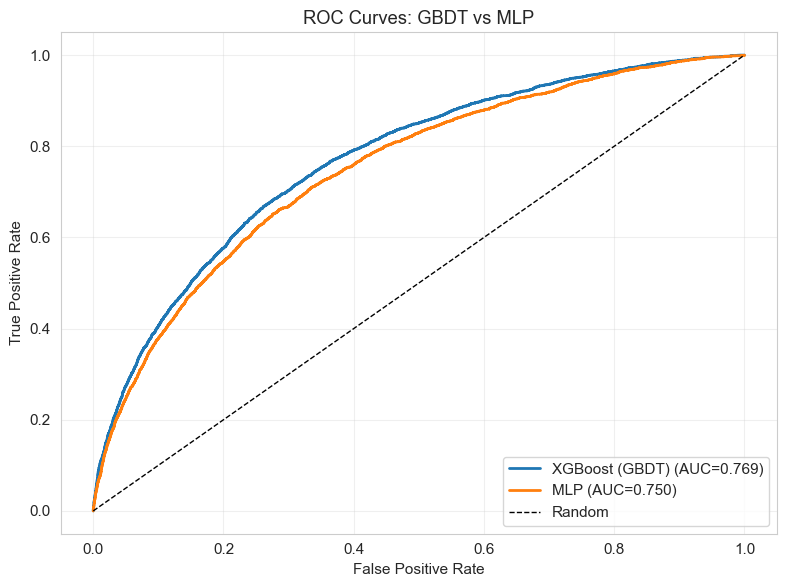

In [33]:
# --- Step 4.4: ROC curves ---
fig, ax = plt.subplots(figsize=(8, 6))

for name, y_proba in [
    ('XGBoost (GBDT)', y_proba_xgb_final),
    ('MLP', y_proba_mlp_final)
]:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', lw=2)

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves: GBDT vs MLP')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

### Discussion: GBDT vs MLP

**1. When would you prefer GBDT over MLP, and vice versa?**
- *GBDT:* Tabular data with mixed feature types, moderate dimensionality, need for interpretability, limited compute budget. GBDT excels when features have non-linear interactions that axis-aligned splits can capture efficiently.
- *MLP:* High-dimensional data, when feature interactions are complex and non-axis-aligned, when you have large datasets and compute available, or when the data has been carefully preprocessed and scaled.

**2. How does interpretability differ?**
- GBDT provides direct feature importance (gain, weight, cover) — practitioners can identify which features drive predictions.
- MLP is a "black box" — weights are distributed across layers, making it difficult to trace individual feature contributions without additional techniques (SHAP, LIME).

**3. How does each model handle categorical features and missing values?**
- GBDT (XGBoost) natively handles missing values by learning optimal split directions for NaN. It can work with label-encoded categoricals.
- MLP requires explicit preprocessing: missing value imputation, one-hot encoding, and feature scaling. We mitigated the imputation information loss using missing indicator flags.

**4. Which model is more sensitive to hyperparameter choices?**
- MLP is generally more sensitive: learning rate, architecture, alpha (regularization), and scaling all significantly impact performance. Poor choices can cause divergence or severe underfitting.
- GBDT is more robust: default parameters often give reasonable results. Early stopping provides automatic regularization. Learning rate mainly affects training speed vs. precision trade-off.

---

## AI Tool Disclosure

- **AI Tools Used:** Gemini Pro and Antigravity
- **Contribution of AI Tools:** Assisted with code generation for the data preprocessing pipeline and notebook structure, dataset exploration, and iterative refinement of feature engineering strategy through Socratic dialogue.
- **Personal Contribution:** All strategic decisions (feature selection, encoding strategy, imbalance handling, experimental design for controlled comparison) were made through guided reasoning. Hyperparameter choices and model interpretation are based on understanding of the underlying algorithms.